In [ ]:
import matplotlib.pyplot as plt
import requests
import pandas as pd
import os
from fredapi import Fred
import pandas as pd
import re

API_KEY = os.getenv("FRED_API_KEY")

url = "https://api.stlouisfed.org/fred/series/search"
# fred = Fred(api_key=os.getenv("FRED_API_KEY"))

def get_FRED_series_ids(search_text="AA corporate bond"):
    params = {
        "search_text": search_text,
        "api_key": API_KEY,
        "file_type": "json"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Extract series list
    series = data["seriess"]
    
    # Convert to DataFrame
    df = pd.DataFrame(series)
    
    # Show some useful columns
    cols = ["id", "title", "frequency", "units", "observation_start", "observation_end"]
    # print(df[cols])
    
    # # Optional: save results
    # df.to_csv("fred_series_search.csv", index=False)
    return df

df_AA = get_FRED_series_ids(search_text="AA corporate bond")
df_A = get_FRED_series_ids(search_text="A corporate bond")
df_BBB  = get_FRED_series_ids(search_text="BBB corporate bond")
df_BB  = get_FRED_series_ids(search_text="BB corporate bond")
df_OAS  = get_FRED_series_ids(search_text="corporate bond OAS")
df_HY  = get_FRED_series_ids(search_text="High Yield bond")

In [64]:
df_HY

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,group_popularity,notes
0,BAMLH0A0HYM2,2026-03-14,2026-03-14,ICE BofA US High Yield Index Option-Adjusted S...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:06:01-05,100,100,The ICE BofA Option-Adjusted Spreads (OASs) ar...
1,BAMLH0A0HYM2EY,2026-03-14,2026-03-14,ICE BofA US High Yield Index Effective Yield,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:05:42-05,86,86,This data represents the effective yield of th...
2,BAMLH0A3HYC,2026-03-14,2026-03-14,ICE BofA CCC & Lower US High Yield Index Optio...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:05:44-05,80,80,This data represents the Option-Adjusted Sprea...
3,BAMLH0A1HYBB,2026-03-14,2026-03-14,ICE BofA BB US High Yield Index Option-Adjuste...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:05:57-05,77,77,This data represents the Option-Adjusted Sprea...
4,BAMLH0A3HYCEY,2026-03-14,2026-03-14,ICE BofA CCC & Lower US High Yield Index Effec...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:05:40-05,75,75,This data represents the effective yield of th...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
322,HQMCB59YR,2026-03-14,2026-03-14,59-Year High Quality Market (HQM) Corporate Bo...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:19:51-06,1,1,The spot rate for any maturity is defined as t...
323,HQMCB54Y6M,2026-03-14,2026-03-14,54.5-Year High Quality Market (HQM) Corporate ...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:20:17-06,1,1,The spot rate for any maturity is defined as t...
324,HQMCB79YR,2026-03-14,2026-03-14,79-Year High Quality Market (HQM) Corporate Bo...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:19:42-06,1,1,The spot rate for any maturity is defined as t...
325,BAMLEMIBHGCRPISYTW,2026-03-14,2026-03-14,ICE BofA High Grade Emerging Markets Corporate...,1998-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:05:56-05,4,4,This data represents the semi-annual yield to ...


In [96]:
year_points = [1,2,3,4,5,10,15,20,25,30]
dfs = pd.concat([df_AA,df_A,df_BBB,df_BB,df_HY])
dfs = df_AA
df = pd.DataFrame([t for i,t in dfs.iterrows() if re.search(r"^\d+-Year", t['title']) and "Bond Spot Rate" in t['title']])
df["year"] = df["title"].str.extract(r"(\d+)").astype(int)
df = df[[y in year_points for y in df['year'].tolist()]]
print(df.shape)
df = df.sort_values(by="year")
display(df.head(20),width=200)

(10, 17)


,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,group_popularity,notes,year
12,HQMCB1YR,2026-03-14,2026-03-14,1-Year High Quality Market (HQM) Corporate Bon...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:20:16-06,28,28,The spot rate for any maturity is defined as t...,1
18,HQMCB2YR,2026-03-14,2026-03-14,2-Year High Quality Market (HQM) Corporate Bon...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:20:23-06,19,19,The spot rate for any maturity is defined as t...,2
16,HQMCB3YR,2026-03-14,2026-03-14,3-Year High Quality Market (HQM) Corporate Bon...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:20:18-06,24,24,The spot rate for any maturity is defined as t...,3
22,HQMCB4YR,2026-03-14,2026-03-14,4-Year High Quality Market (HQM) Corporate Bon...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:20:08-06,10,10,The spot rate for any maturity is defined as t...,4
5,HQMCB5YR,2026-03-14,2026-03-14,5-Year High Quality Market (HQM) Corporate Bon...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:19:49-06,40,40,The spot rate for any maturity is defined as t...,5
2,HQMCB10YR,2026-03-14,2026-03-14,10-Year High Quality Market (HQM) Corporate Bo...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:20:02-06,50,50,The spot rate for any maturity is defined as t...,10
8,HQMCB15YR,2026-03-14,2026-03-14,15-Year High Quality Market (HQM) Corporate Bo...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:20:17-06,34,34,The spot rate for any maturity is defined as t...,15
3,HQMCB20YR,2026-03-14,2026-03-14,20-Year High Quality Market (HQM) Corporate Bo...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:20:25-06,45,45,The spot rate for any maturity is defined as t...,20
19,HQMCB25YR,2026-03-14,2026-03-14,25-Year High Quality Market (HQM) Corporate Bo...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:20:15-06,16,16,The spot rate for any maturity is defined as t...,25
9,HQMCB30YR,2026-03-14,2026-03-14,30-Year High Quality Market (HQM) Corporate Bo...,1984-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 14:20:11-06,34,34,The spot rate for any maturity is defined as t...,30


In [ ]:
df['title'].tolist()

print(df.groupby("frequency").size().reset_index(name="count"))

ids = df['id'].tolist()
ids, year_points

In [ ]:
data = {}
fred = Fred(api_key=os.getenv("FRED_API_KEY"))
for y, fred_id in zip(year_points,ids):
    data[y] = fred.get_series(fred_id)

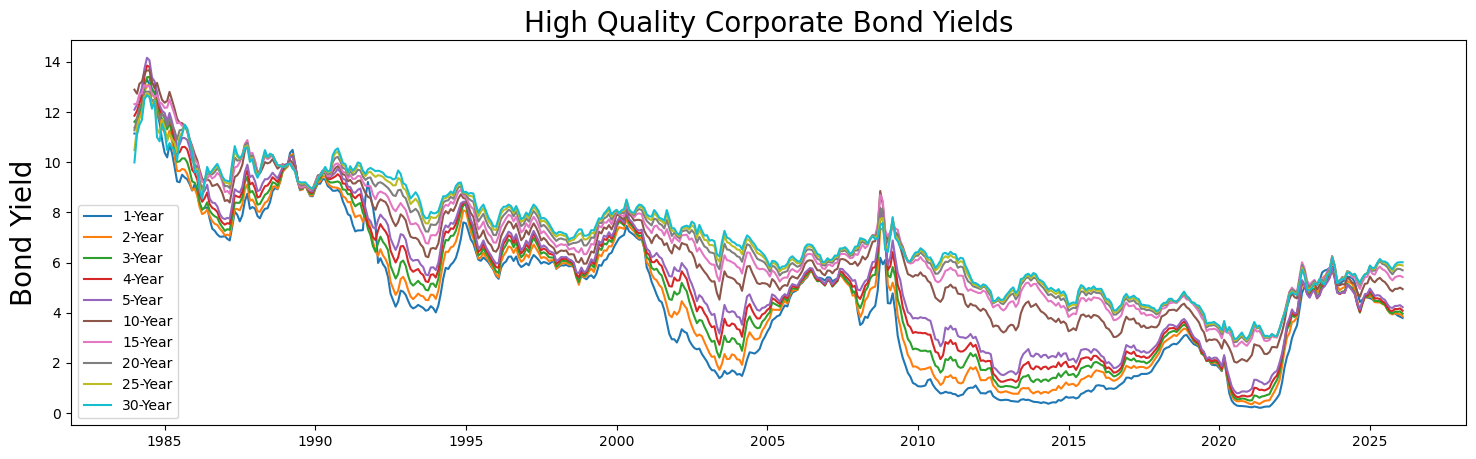

In [118]:
plt.figure(figsize=(18,5))
for y in year_points:
    plt.plot(data[y], label=str(y) + "-Year")
plt.legend()
plt.title("High Quality Corporate Bond Yields", fontsize=20)
plt.ylabel("Bond Yield", fontsize=20)
plt.show()

(506, 10)


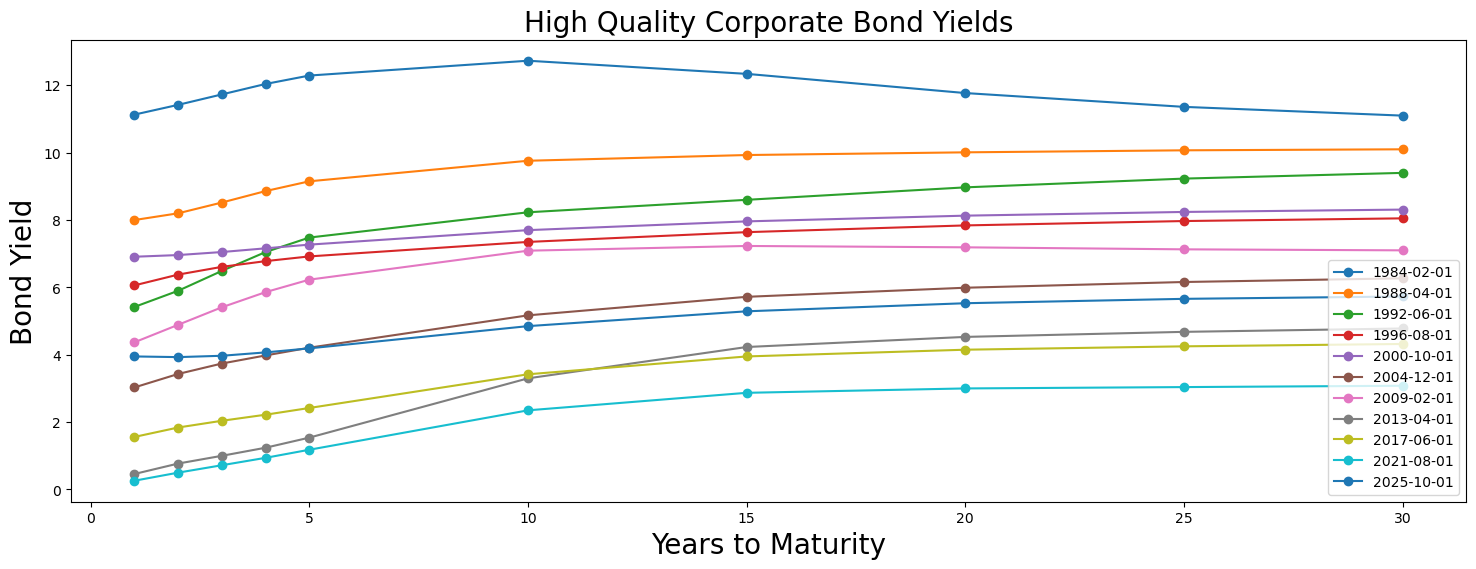

In [144]:
yc = pd.DataFrame(data)
print(yc.shape)

plt.figure(figsize=(18,6))
for i in range(1, yc.shape[0], 50):
    plt.plot(yc.iloc[i,:], 'o-', label=str(yc.index[i])[:10])
plt.legend()
plt.title("High Quality Corporate Bond Yields", fontsize=20)
plt.ylabel("Bond Yield", fontsize=20)
plt.xlabel("Years to Maturity", fontsize=20)
plt.show()

In [122]:
print(df_OAS.shape)
df_OAS[:2]

(48, 16)


,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,group_popularity,notes
0,BAMLC0A4CBBB,2026-03-14,2026-03-14,ICE BofA BBB US Corporate Index Option-Adjuste...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:06:46-05,86,86,This data represents the Option-Adjusted Sprea...
1,BAMLC0A0CM,2026-03-14,2026-03-14,ICE BofA US Corporate Index Option-Adjusted Sp...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:06:49-05,86,86,The ICE BofA Option-Adjusted Spreads (OASs) ar...


In [123]:
df_OAS['title'].to_list()

['ICE BofA BBB US Corporate Index Option-Adjusted Spread',
 'ICE BofA US Corporate Index Option-Adjusted Spread',
 'ICE BofA CCC & Lower US High Yield Index Option-Adjusted Spread',
 'ICE BofA BB US High Yield Index Option-Adjusted Spread',
 'ICE BofA Single-B US High Yield Index Option-Adjusted Spread',
 'ICE BofA Single-A US Corporate Index Option-Adjusted Spread',
 'ICE BofA AAA US Corporate Index Option-Adjusted Spread',
 'ICE BofA AA US Corporate Index Option-Adjusted Spread',
 'ICE BofA Emerging Markets Corporate Plus Index Option-Adjusted Spread',
 'ICE BofA 7-10 Year US Corporate Index Option-Adjusted Spread',
 'ICE BofA 1-3 Year US Corporate Index Option-Adjusted Spread',
 'ICE BofA 3-5 Year US Corporate Index Option-Adjusted Spread',
 'ICE BofA Asia Emerging Markets Corporate Plus Index Option-Adjusted Spread',
 'ICE BofA BBB Emerging Markets Corporate Plus Index Option-Adjusted Spread',
 'ICE BofA BB Emerging Markets Corporate Plus Index Option-Adjusted Spread',
 'ICE BofA L

In [137]:
df_OAS_ = pd.DataFrame([t for i,t in df_OAS.iterrows() if re.search(r"\d+ Year", t['title']) and "Index Option-Adjusted Spread" in t['title']])

df_OAS_['years'] = [re.search(r"ICE BofA\s+(.*?)\s+Year", text).group(1) for text in df_OAS_['title'].to_list()]
df_OAS_["year one"] = df_OAS_["years"].str.extract(r"(\d+)").astype(int)
df_OAS_ = df_OAS_.sort_values('year one')
df_OAS_

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,group_popularity,notes,years,year one
10,BAMLC1A0C13Y,2026-03-14,2026-03-14,ICE BofA 1-3 Year US Corporate Index Option-Ad...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:06:56-05,44,44,The ICE BofA Option-Adjusted Spreads (OASs) ar...,1-3,1
11,BAMLC2A0C35Y,2026-03-14,2026-03-14,ICE BofA 3-5 Year US Corporate Index Option-Ad...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:06:53-05,43,43,The ICE BofA Option-Adjusted Spreads (OASs) ar...,3-5,3
17,BAMLC3A0C57Y,2026-03-14,2026-03-14,ICE BofA 5-7 Year US Corporate Index Option-Ad...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:06:57-05,33,33,The ICE BofA Option-Adjusted Spreads (OASs) ar...,5-7,5
9,BAMLC4A0C710Y,2026-03-14,2026-03-14,ICE BofA 7-10 Year US Corporate Index Option-A...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:06:54-05,44,44,The ICE BofA Option-Adjusted Spreads (OASs) ar...,7-10,7
20,BAMLC7A0C1015Y,2026-03-14,2026-03-14,ICE BofA 10-15 Year US Corporate Index Option-...,1996-12-31,2026-03-12,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-13 10:06:41-05,25,25,The ICE BofA Option-Adjusted Spreads (OASs) ar...,10-15,10


In [138]:
OAS_data = {}
fred = Fred(api_key=os.getenv("FRED_API_KEY"))
for i,r in df_OAS_.iterrows():
    y, fred_id = r['years'], r['id']
    OAS_data[y] = fred.get_series(fred_id)

In [140]:
OAS_df = pd.DataFrame(OAS_data)
OAS_df

,1-3,3-5,5-7,7-10,10-15
1996-12-31,0.47,0.50,0.58,0.62,0.65
1997-01-01,NaN,NaN,NaN,NaN,NaN
1997-01-02,0.48,0.51,0.58,0.61,0.64
1997-01-03,0.48,0.51,0.58,0.62,0.63
1997-01-06,0.48,0.51,0.58,0.62,0.64
...,...,...,...,...,...
2026-03-06,0.53,0.74,0.86,0.98,1.00
2026-03-09,0.54,0.75,0.87,0.99,1.01
2026-03-10,0.55,0.74,0.86,0.98,1.00
2026-03-11,0.58,0.77,0.89,1.02,1.03


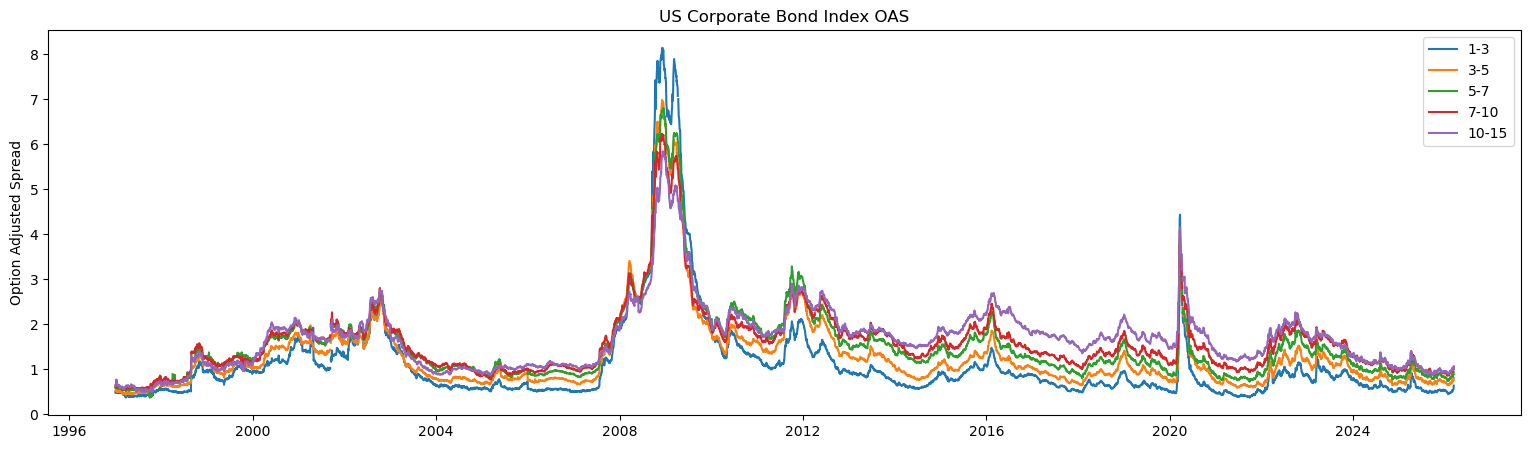

In [143]:
plt.figure(figsize=(19,5))
plt.plot(OAS_df, label=OAS_df.columns)
plt.legend()
plt.title("US Corporate Bond Index OAS")
plt.ylabel("Option Adjusted Spread")
plt.show()

(7718, 5)


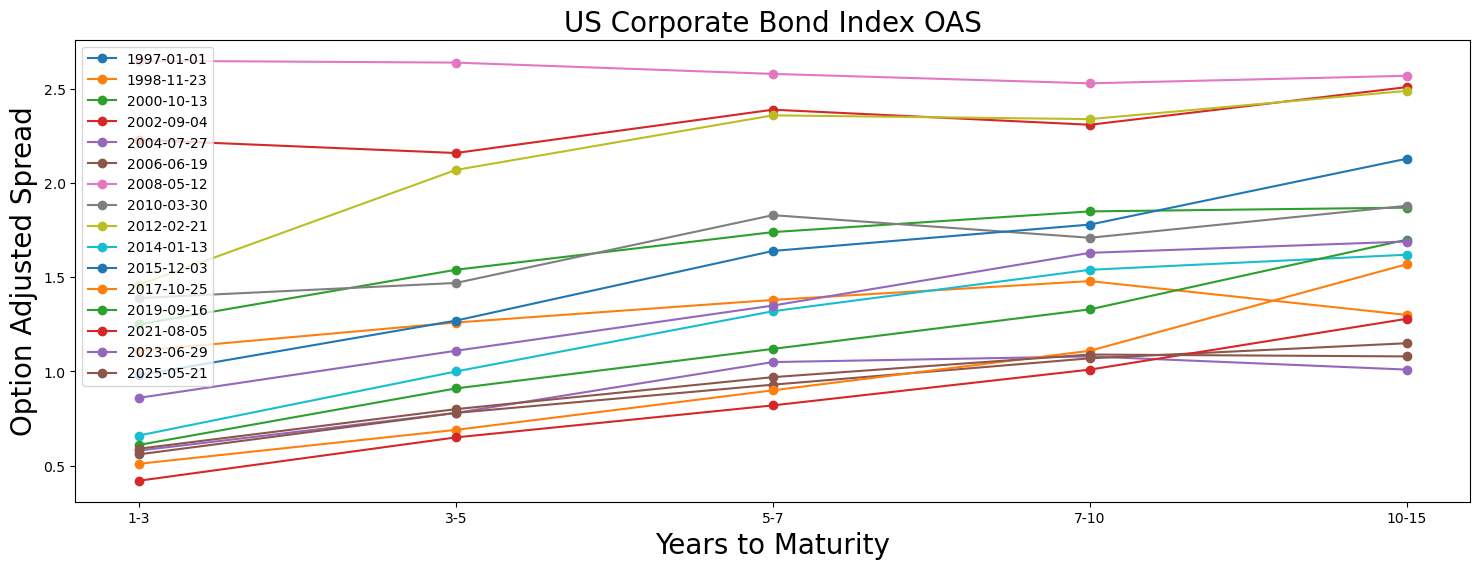

In [158]:
OAS_yc = OAS_df#.transpose()
print(OAS_yc.shape)

plt.figure(figsize=(18,6))
for i in range(1, OAS_yc.shape[0], 500):
    plt.plot(OAS_yc.iloc[i,:], 'o-', label=str(OAS_yc.index[i])[:10])
plt.legend()
plt.title("US Corporate Bond Index OAS", fontsize=20)
plt.ylabel("Option Adjusted Spread", fontsize=20)
plt.xlabel("Years to Maturity", fontsize=20)
plt.show()

In [160]:
!pip install --upgrade matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


dict_keys(['HQMCB1YR', 'HQMCB2YR', 'HQMCB3YR'])
1984-01-01    11.61
1984-02-01    11.73
1984-03-01    12.01
1984-04-01    12.35
1984-05-01    13.02
              ...  
2025-10-01     3.97
2025-11-01     4.05
2025-12-01     4.03
2026-01-01     4.05
2026-02-01     3.96
Length: 506, dtype: float64
<class 'pandas.Series'>


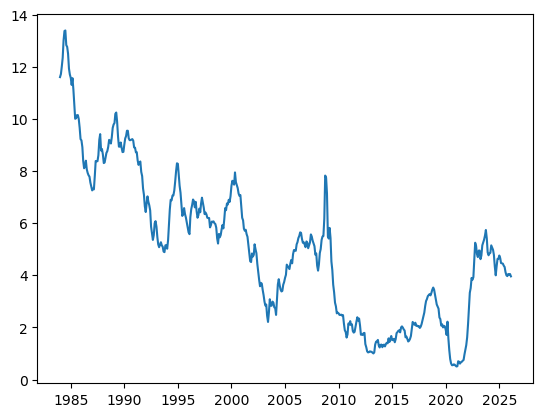

In [81]:
print(data.keys())
print(data['HQMCB3YR'])
print(type(data['HQMCB3YR']))
plt.plot(data['HQMCB3YR'])
plt.show()

In [ ]:
df_OAS  = get_FRED_series_ids(search_text="corporate bond OAS")
df_HY  = get_FRED_series_ids(search_text="High Yield bond")

print(df_OAS)
print(df_HY)

In [ ]:
pd.set_option("display.width", 150)        # total console width
pd.set_option("display.max_colwidth", 100) # max width per column
pd.set_option("display.max_columns", None) # show all columns
pd.set_option("display.max_rows", 1000)      # rows before truncation

display(df_AA[["id","title"]].sort_values(by="title").head())
display(df_A[["id","title"]].sort_values(by="title").head())
display(df_BBB[["id","title"]].sort_values(by="title").head())
display(df_BB[["id","title"]].sort_values(by="title").head())

In [ ]:
"""
💡 Most common academic spread series
BAMLH0A0HYM2 → High Yield OAS
BAMLC0A0CM → Investment Grade OAS
BAMLC0A4CBBB → BBB OAS
BAA10Y → Moody’s Baa − Treasury
"""
dfs = pd.concat([df_AA,df_A,df_BBB,df_BB, df_HY])
dfs.shape, df_AA.shape

In [ ]:
dfs[['10-Year' in t for t in dfs.loc[:,"title"]]][["id","title"]].sort_values("title")

In [ ]:

"""
💡 Most common academic spread series
BAMLH0A0HYM2 → High Yield OAS
BAMLC0A0CM → Investment Grade OAS
BAMLC0A4CBBB → BBB OAS
BAA10Y → Moody’s Baa − Treasury
"""
fred = Fred(api_key=os.getenv("FRED_API_KEY"))
# High yield spread
hy = fred.get_series("BAMLH0A0HYM2")

# Investment grade spread
ig = fred.get_series("BAMLC0A0CM")

# BBB spread
bbb = fred.get_series("BAMLC0A4CBBB")

df = pd.concat([hy, ig, bbb], axis=1)
df.columns = ["HY_OAS", "IG_OAS", "BBB_OAS"]

# df.to_csv("us_corporate_spreads.csv")

In [ ]:
plt.plot(df,label=df.columns)
plt.legend()
plt.show()

In [ ]:
from fredapi import Fred
import pandas as pd

# fred = Fred(api_key="YOUR_FRED_API_KEY")
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

# Corporate bond OAS series by rating
tickers = {
    "AAA": {
        "ticker": "BAMLC0A1CAAA",
        "description": "ICE BofA AAA US Corporate Index Option-Adjusted Spread (OAS). "
                       "Measures the spread of AAA-rated US investment-grade corporate bonds "
                       "over the Treasury curve, adjusted for embedded options."
    },
    "AA": {
        "ticker": "BAMLC0A2CAA",
        "description": "ICE BofA AA US Corporate Index Option-Adjusted Spread (OAS). "
                       "Represents the credit spread of AA-rated US corporate bonds "
                       "relative to Treasury securities after adjusting for option risk."
    },
    "A": {
        "ticker": "BAMLC0A3CA",
        "description": "ICE BofA Single-A US Corporate Index Option-Adjusted Spread (OAS). "
                       "Tracks the spread of A-rated investment-grade corporate bonds "
                       "over the Treasury curve."
    },
    "BBB": {
        "ticker": "BAMLC0A4CBBB",
        "description": "ICE BofA BBB US Corporate Index Option-Adjusted Spread (OAS). "
                       "Measures the spread of the lowest investment-grade corporate bonds "
                       "relative to Treasuries."
    },
    "BB": {
        "ticker": "BAMLH0A1HYBB",
        "description": "ICE BofA BB US High Yield Index Option-Adjusted Spread (OAS). "
                       "Captures the credit spread of BB-rated high-yield corporate bonds "
                       "relative to Treasury securities."
    },
    "B": {
        "ticker": "BAMLH0A2HYB",
        "description": "ICE BofA Single-B US High Yield Index Option-Adjusted Spread (OAS). "
                       "Measures spreads of B-rated speculative-grade corporate bonds."
    },
    "CCC": {
        "ticker": "BAMLH0A3HYC",
        "description": "ICE BofA CCC & Lower US High Yield Index Option-Adjusted Spread (OAS). "
                       "Tracks the spread of the lowest-rated distressed corporate bonds "
                       "(CCC and below) relative to Treasuries."
    }
}

# Download data
data = {}
for rating, info in tickers.items():
    data[rating] = fred.get_series(info["ticker"])

df = pd.DataFrame(data)

# Optional: print metadata
for rating, info in tickers.items():
    print(f"{rating} ({info['ticker']}): {info['description']}")

# df.to_csv("corporate_oas_by_rating.csv")

In [ ]:
plt.plot(df,label=df.columns)
plt.legend()
plt.show()

In [ ]:
from fredapi import Fred
import pandas as pd

# Put your FRED API key here
# fred = Fred(api_key="YOUR_FRED_API_KEY")
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

# Maturity buckets for ICE BofA US Corporate OAS
series = {
    "1-3Y": {
        "ticker": "BAMLC1A0C13Y",
        "description": "ICE BofA 1–3 Year US Corporate Index Option-Adjusted Spread"
    },
    "3-5Y": {
        "ticker": "BAMLC2A0C35Y",
        "description": "ICE BofA 3–5 Year US Corporate Index Option-Adjusted Spread"
    },
    "5-7Y": {
        "ticker": "BAMLC3A0C57Y",
        "description": "ICE BofA 5–7 Year US Corporate Index Option-Adjusted Spread"
    },
    "7-10Y": {
        "ticker": "BAMLC4A0C710Y",
        "description": "ICE BofA 7–10 Year US Corporate Index Option-Adjusted Spread"
    },
    "10-15Y": {
        "ticker": "BAMLC5A0C1015Y",
        "description": "ICE BofA 10–15 Year US Corporate Index Option-Adjusted Spread"
    },
    "15Y+": {
        "ticker": "BAMLC6A0C15PY",
        "description": "ICE BofA 15+ Year US Corporate Index Option-Adjusted Spread"
    }
}

# Download data
data = {}
for bucket, info in series.items():
    ticker = info["ticker"]
    print(f"Downloading {bucket} ({ticker})")
    try:
        data[bucket] = fred.get_series(ticker)
    except:
        pass

# Create dataframe
df = pd.DataFrame(data)

# Save results
# df.to_csv("corporate_oas_by_maturity.csv")

# print("\nDownloaded series:")
# for bucket, info in series.items():
#     print(f"{bucket}: {info['ticker']} — {info['description']}")

# print("\nData shape:", df.shape)

plt.plot(df,label=df.columns)
plt.legend()
plt.show()

In [ ]:
fred_dir = "Fred corp bond spreads"
fnames = ['AAA10Y.xls','BAA10Y.xls']


fred.get_series("BAMLC0A4CBBB")